# 🎤 Speech Emotion Recognition using Deep Learning

## CodeAlpha Machine Learning Internship

### Project Overview

Speech Emotion Recognition (SER) is the task of identifying human emotions from speech audio using machine learning and deep learning techniques.

In this project, audio recordings will be processed to extract meaningful acoustic features such as Mel-Frequency Cepstral Coefficients (MFCCs). A deep learning model will then classify speech into different emotional categories.

The project follows a complete machine learning workflow including:

- Dataset Exploration
- Audio Preprocessing
- Feature Extraction
- Deep Learning Model Development
- Model Evaluation
- Streamlit Deployment

# Project Objectives

The objectives of this project are:

- Understand the Speech Emotion Recognition problem.
- Explore the RAVDESS speech dataset.
- Perform audio preprocessing.
- Extract MFCC features from speech signals.
- Train a deep learning model for emotion classification.
- Evaluate model performance using standard metrics.
- Save the trained model.
- Build a Streamlit application for emotion prediction.

# Technologies Used

- Python
- TensorFlow / Keras
- Librosa
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Streamlit

# Table of Contents

1. Import Libraries
2. Dataset Loading
3. Dataset Exploration
4. Audio Visualization
5. Audio Preprocessing
6. MFCC Feature Extraction
7. Dataset Preparation
8. CNN Model Development
9. Model Training
10. Model Evaluation
11. Save Model
12. Streamlit Deployment
13. Conclusion

# Import Libraries

In [12]:
# File Handling
import os

# Numerical Computing
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Audio Processing
import librosa
import librosa.display

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv1D,
    MaxPooling1D,
    Dropout,
    Flatten,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Dataset Loading

The RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) dataset contains speech recordings from multiple actors expressing different emotions.

Unlike traditional machine learning datasets that are stored as CSV files, this dataset consists of audio files organized into folders. Therefore, the first step is to scan the dataset directory, read each audio file, extract its corresponding emotion label from the filename, and organize the information into a structured pandas DataFrame for further analysis.

In [13]:
emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised"
}

In [14]:
file_paths = []
emotions = []
actors = []

In [15]:
dataset_path = "dataset"

print("Dataset exists:", os.path.exists(dataset_path))

Dataset exists: True


In [16]:
dataset_path = "dataset"

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                parts = file.split("-")

                emotion_code = parts[2]

                actor_id = parts[-1].replace(".wav", "")

                file_paths.append(os.path.join(actor_path, file))

                emotions.append(emotion_map[emotion_code])

                actors.append(actor_id)

In [18]:
df = pd.DataFrame({
    "File_Path": file_paths,
    "Emotion": emotions,
    "Actor": actors
})

In [19]:
df.head()

,File_Path,Emotion,Actor
0,dataset\Actor_01\03-01-01-01-01-01-01.wav,Neutral,01
1,dataset\Actor_01\03-01-01-01-01-02-01.wav,Neutral,01
2,dataset\Actor_01\03-01-01-01-02-01-01.wav,Neutral,01
3,dataset\Actor_01\03-01-01-01-02-02-01.wav,Neutral,01
4,dataset\Actor_01\03-01-02-01-01-01-01.wav,Calm,01


In [20]:
print(df.shape)

(1440, 3)


In [21]:
df["Emotion"].value_counts()

Emotion
Calm         192
Happy        192
Sad          192
Angry        192
Fearful      192
Disgust      192
Surprised    192
Neutral       96
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the structure and characteristics of the Speech Emotion Recognition dataset before training a deep learning model.

The objectives of this section are to:

- Understand the distribution of emotion classes.
- Verify that the dataset is balanced.
- Check for missing or duplicate records.
- Explore the actor distribution.
- Inspect sample audio recordings before feature extraction.

Performing EDA helps identify potential issues in the dataset and provides insights that guide preprocessing and model development.

In [22]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (1440, 3)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   File_Path  1440 non-null   str  
 1   Emotion    1440 non-null   str  
 2   Actor      1440 non-null   str  
dtypes: str(3)
memory usage: 102.5 KB


In [23]:
df.describe(include="object")

,File_Path,Emotion,Actor
count,1440,1440,1440
unique,1440,8,24
top,dataset\Actor_01\03-01-01-01-01-01-01.wav,Calm,01
freq,1,192,60


In [24]:
df.isnull().sum()

File_Path    0
Emotion      0
Actor        0
dtype: int64

In [25]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


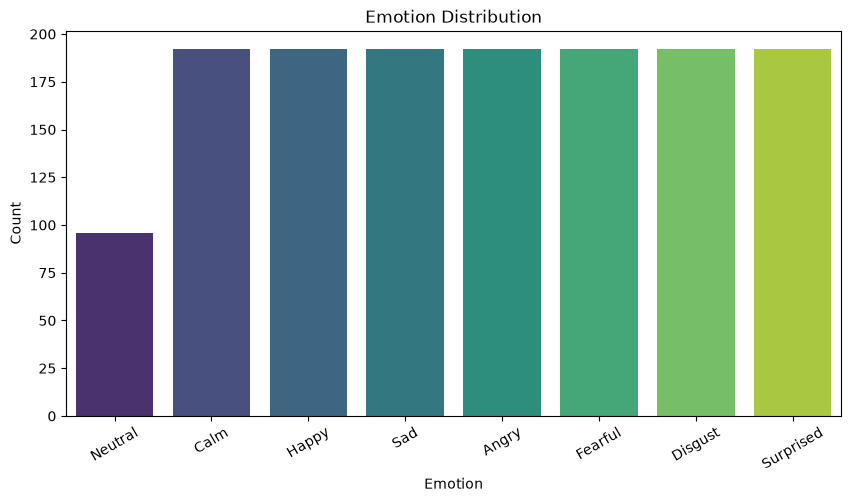

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Emotion",
    hue="Emotion",
    palette="viridis",
    legend=False
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

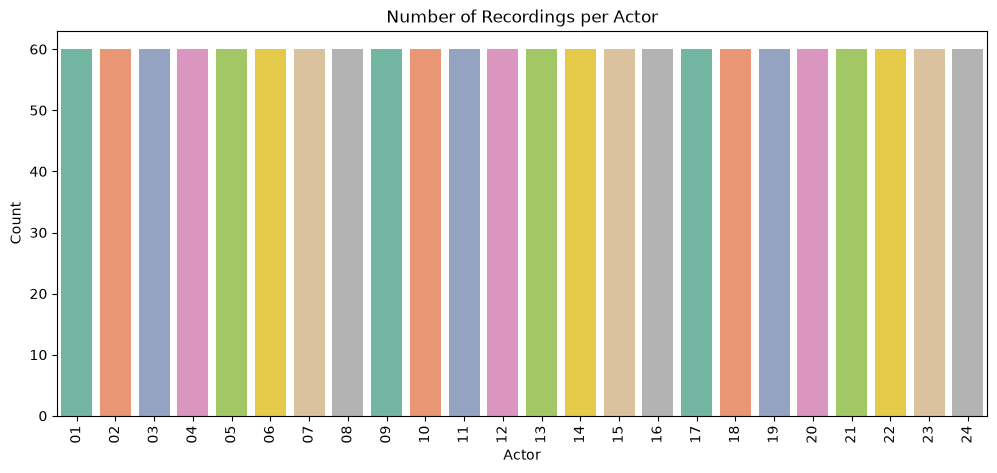

In [27]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Actor",
    hue="Actor",
    palette="Set2",
    legend=False
)

plt.title("Number of Recordings per Actor")
plt.xlabel("Actor")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [28]:
sample_audio = df.iloc[0]["File_Path"]

print(sample_audio)

dataset\Actor_01\03-01-01-01-01-01-01.wav


In [29]:
signal, sample_rate = librosa.load(
    sample_audio,
    sr=None
)

In [31]:
print("Signal Shape:", signal.shape)

print("Sample Rate:", sample_rate)

Signal Shape: (158558,)
Sample Rate: 48000


# MFCC Feature Extraction

Raw audio signals contain thousands of amplitude values that are difficult for machine learning models to interpret directly.

To obtain meaningful information from speech recordings, Mel-Frequency Cepstral Coefficients (MFCCs) are extracted. MFCCs provide a compact representation of speech characteristics by emphasizing frequencies that are important to human hearing.

These extracted features will be used as input to the deep learning model for emotion classification.

# Audio Signal Visualization

Before extracting numerical features from the speech recordings, it is important to understand the structure of the raw audio signal.

An audio recording is represented as a sequence of amplitude values sampled over time. By visualizing the waveform, we can observe how the sound intensity changes throughout the recording.

In this section, we will:

- Load a sample audio recording.
- Visualize its waveform.
- Understand the sampling rate and signal length.
- Prepare the audio for feature extraction in the next stage.